<a href="https://colab.research.google.com/github/bemakerorg/AIoT_Book_II_RF/blob/main/AIOT_RF_Book_ES_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# CELLA 1 - Verifica versioni librerie e installa eventuali downgrade
import tensorflow as tf  # Framework per machine learning
import tensorflow_hub as hub # TensorFlow Hub: per utilizzare modelli pre-addestrati condivisi
import numpy as np  # Libreria per calcoli numerici
import PIL  # Libreria per manipolazione immagini
import sklearn  # Libreria per machine learning
import matplotlib  # Libreria per grafici
import os  # Libreria per operazioni su file system
import pathlib  # Libreria per gestione percorsi
import time # Import time module for timing
!pip install roboflow --quiet  # Installa Roboflow in modalità silenziosa
import pillow_heif
import matplotlib.pyplot as plt  # Libreria per grafici

from roboflow import Roboflow  # Importa SDK Roboflow
from getpass import getpass  # Importa per input sicuro password
from collections import Counter
from tqdm import tqdm  # Libreria per visualizzare barre di progresso
from google.colab import files  # Importa per upload file
from tensorflow.keras.preprocessing import image  # Importa preprocessing immagini
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay  # Metriche


print("TensorFlow:", tf.__version__)  # Verifica versione TensorFlow
print("TensorFlow_Hub:", hub.__version__)  # Verifica versione TensorFlow Hub
print("NumPy:", np.__version__)  # Verifica versione NumPy
print("Pillow:", PIL.__version__)  # Verifica versione Pillow
print("Scikit-learn:", sklearn.__version__)  # Verifica versione Scikit-learn
print("Matplotlib:", matplotlib.__version__)  # Verifica versione Matplotlib
print("Pillow Heif:", pillow_heif.__version__)  # Verifica versione pillow_heif

# Versioni richieste
# Qui definiamo le versioni specifiche delle librerie necessarie per garantire compatibilità e riproducibilità
tf_version = "2.18.0"                 # Versione di TensorFlow desiderata
hub_version = "0.16.1"                # Versione di TensorFlow Hub desiderata
np_version = "2.0.2"                  # Versione di NumPy desiderata
PIL_version = "11.2.1"                 # Versione Pillow desiderata
sklearn_version = "1.6.1"             # Versione Scikit-learn desiderata
matplotlib_version = "3.10.0"          # Versione Matplotlib desiderata
pillow_heif_version = "1.0.0"         # Versione pillow_heif desiderata

# Controlliamo le versioni dei pacchetti e agiamo di conseguenza
if (tf.__version__ != tf_version or  # Verifica se la versione corrente di TensorFlow è diversa da quella richiesta
    hub.__version__ != hub_version or  # Verifica la versione di TensorFlow Hub
    np.__version__ != np_version or  # Verifica la versione di NumPy
    PIL.__version__ != PIL_version or  # Verifica la versione di Pillow
    sklearn.__version__ != sklearn_version or  # Verifica la versione di Scikit-learn
    matplotlib.__version__ != matplotlib_version or  # Verifica la versione di Matplotlib
    pillow_heif.__version__ != pillow_heif_version): # Verifica versione pillow_heif

    # Notifica all'utente le versioni attuali e quelle che verranno installate
    print(f"Versione TensorFlow corrente: {tf.__version__}, switching a {tf_version}")
    print(f"Versione TensorFlow Hub corrente: {hub.__version__}, switching a {hub_version}")
    print(f"Versione NumPy corrente: {np.__version__}, switching a {np_version}")
    print(f"Versione Pillow corrente: {PIL.__version__}, switching a {PIL_version}")
    print(f"Versione Scikit-learn corrente: {sklearn.__version__}, switching a {sklearn_version}")
    print(f"Versione Matplotlib corrente: {matplotlib.__version__}, switching a {matplotlib_version}")
    print(f"Versione pillow_heif corrente: {pillow_heif.__version__}, switching a {pillow_heif_version}")

    # Disinstalliamo le versioni correnti dei pacchetti (se necessario)
    !pip uninstall -y tensorflow tensorflow_hub numpy PIL sklearn matplotlib pillow_heif

    # Installiamo le versioni richieste dei pacchetti specificati
    !pip install tensorflow==2.18.0 tensorflow_hub==0.16.1 numpy==2.0.2 pillow==11.2.1 scikit-learn==1.6.1 matplotlib==3.10.0 pillow_heif==1.0.0

    # Informiamo l'utente che è necessario riavviare il runtime per applicare i cambiamenti
    print("Le versioni specificate delle librerie sono state installate.")
    print("Prego cliccare su Runtime > Restart session and run all.")
else:
    # Se tutte le versioni corrispondono a quelle richieste, lo segnaliamo all'utente
    print("Tutti i pacchetti sono nelle versioni specificate")

TensorFlow: 2.18.0
TensorFlow_Hub: 0.16.1
NumPy: 2.0.2
Pillow: 11.2.1
Scikit-learn: 1.6.1
Matplotlib: 3.10.0
Pillow Heif: 1.0.0
Tutti i pacchetti sono nelle versioni specificate


In [7]:
# CELLA 2 - Download dataset da Roboflow con struttura folder
# 🔑 Richiedi API Key in modo sicuro
api_key = getpass("Inserisci la tua Roboflow PRIVATE API Key: ")  # Input sicuro API key
rf = Roboflow(api_key=api_key)  # Inizializza client Roboflow

# 📥 Download dataset "face_vww" in formato folder
face_project = rf.workspace().project("face_vww")  # Connetti al progetto face
face_version = face_project.version(1)  # Seleziona versione 1
face_dataset = face_version.download("folder")  # Scarica in formato folder

# 📥 Download dataset "no_face" in formato folder
no_face_project = rf.workspace().project("no_face_vww")  # Connetti al progetto no_face
no_face_version = no_face_project.version(1)  # Seleziona versione 1
no_face_dataset = no_face_version.download("folder")  # Scarica in formato folder

print(f"\n📂 Dataset face_vww scaricato in: {face_dataset.location}")  # Stampa percorso face
print(f"\n📂 Dataset no_face scaricato in: {no_face_dataset.location}")  # Stampa percorso no_face

Inserisci la tua Roboflow PRIVATE API Key: ··········
loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...

📂 Dataset face_vww scaricato in: /content/Face_VWW-1

📂 Dataset no_face scaricato in: /content/No_Face_VWW-1


In [8]:
# CELLA 3 - Caricamento immagini

def count_images_in_folder(folder):
    """Conta file immagine in una cartella specifica"""
    if not os.path.exists(folder):  # Verifica esistenza cartella
        return 0  # Ritorna 0 se cartella non esiste
    return len([f for f in os.listdir(folder)  # Conta file
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))])  # Solo immagini

# Definisci percorsi corretti basati sulla struttura reale
face_base = face_dataset.location  # Percorso base dataset face
no_face_base = no_face_dataset.location  # Percorso base dataset no_face

print(f"📂 Percorso base Face: {face_base}")  # Stampa percorso face
print(f"📂 Percorso base No_Face: {no_face_base}")  # Stampa percorso no_face

# Definisci percorsi specifici per ogni split e classe - vedere video su Roboflow per capire gestione percorsi
face_paths = {  # Dizionario percorsi face
    "train": os.path.join(face_base, "train", "Face"),  # Percorso train face
    "valid": os.path.join(face_base, "valid", "Face"),  # Percorso valid face
    "test": os.path.join(face_base, "test", "Face")     # Percorso test face
}

no_face_paths = {  # Dizionario percorsi no_face
    "train": os.path.join(no_face_base, "train", "No_Face"),  # Percorso train no_face
    "valid": os.path.join(no_face_base, "valid", "No_Face"),  # Percorso valid no_face
    "test": os.path.join(no_face_base, "test", "No_Face")     # Percorso test no_face
}

# Verifica esistenza cartelle e conta immagini
print("\n🔍 Verifica struttura cartelle e conteggio immagini:")  # Intestazione verifica

face_totals = {}  # Dizionario totali face
no_face_totals = {}  # Dizionario totali no_face

for split in ["train", "valid", "test"]:  # Per ogni split
    # Conta immagini face
    face_dir = face_paths[split]  # Ottieni percorso face
    face_count = count_images_in_folder(face_dir)  # Conta immagini face
    face_totals[split] = face_count  # Salva conteggio

    # Conta immagini no_face
    no_face_dir = no_face_paths[split]  # Ottieni percorso no_face
    no_face_count = count_images_in_folder(no_face_dir)  # Conta immagini no_face
    no_face_totals[split] = no_face_count  # Salva conteggio

# 📊 Calcola totali generali
total_face = sum(face_totals.values())  # Totale face
total_no_face = sum(no_face_totals.values())  # Totale no_face
total_general = total_face + total_no_face  # Totale generale

print(f"\n" + "="*50)  # Separatore
print("📋 RIEPILOGO FINALE DATASET")  # Intestazione finale
print("="*50)  # Separatore
print(f"👤 Totale Face: {total_face} immagini")  # Totale face
print(f"🚫 Totale No_Face: {total_no_face} immagini")  # Totale no_face
print(f"📦 Totale generale: {total_general} immagini")  # Totale generale

# 🎯 Verifica bilanciamento
if total_face > 0 and total_no_face > 0:  # Se entrambi hanno immagini
    ratio = total_face / total_no_face  # Calcola rapporto
    print(f"⚖️ Rapporto Face/No_Face: {ratio:.2f}")  # Stampa rapporto

    if 0.8 <= ratio <= 1.2:  # Se bilanciato
        print("✅ Dataset ben bilanciato")  # Messaggio bilanciato
    else:
        print("⚠️ Dataset sbilanciato")  # Avviso sbilanciamento

📂 Percorso base Face: /content/Face_VWW-1
📂 Percorso base No_Face: /content/No_Face_VWW-1

🔍 Verifica struttura cartelle e conteggio immagini:

📋 RIEPILOGO FINALE DATASET
👤 Totale Face: 1264 immagini
🚫 Totale No_Face: 1294 immagini
📦 Totale generale: 2558 immagini
⚖️ Rapporto Face/No_Face: 0.98
✅ Dataset ben bilanciato


In [9]:
# CELLA 4 - Preparazione dataset combinato FACE + NO_FACE
#--------------------------------------------------------------------

def list_image_paths_and_labels(directory, label):
    """Funzione per elencare percorsi immagini e assegnare etichette"""
    if not os.path.exists(directory):
        print(f"⚠️ Directory non trovata: {directory}")
        return []

    files = [f for f in os.listdir(directory) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    return [(os.path.join(directory, fname), label) for fname in files]

# ✅ Etichette: face=1, no_face=0 (ENTRAMBE LE CLASSI)
datasets = {}
counts_per_split = {}
class_names = ["no_face", "face"]             # ⭐ ORDINE CORRETTO: indice 0=no_face, indice 1=face

for split in ["train", "valid", "test"]:
    # USA I PERCORSI CORRETTI DALLA CELLA 3
    face_dir = face_paths[split]  # Usa percorsi definiti in CELLA 3
    no_face_dir = no_face_paths[split]  # Usa percorsi definiti in CELLA 3

    # Carica ENTRAMBE le classi
    face_data = list_image_paths_and_labels(face_dir, 1)  # Face = etichetta 1
    no_face_data = list_image_paths_and_labels(no_face_dir, 0)  # No_face = etichetta 0

    # BILANCIAMENTO FORZATO - Prendi stesso numero per entrambe le classi
    min_samples = min(len(face_data), len(no_face_data))
    if min_samples > 0:
        face_data = face_data[:min_samples]  # Limita face
        no_face_data = no_face_data[:min_samples]  # Limita no_face

    # Combina entrambe le classi
    combined_data = face_data + no_face_data

    if not combined_data:
        print(f"❌ Nessuna immagine trovata per {split}")
        paths, labels = [], []
    else:
        paths, labels = zip(*combined_data)

    # Salva conteggi per monitoraggio
    label_counts = Counter(labels)
    counts_per_split[split] = label_counts

    # Crea dataset TensorFlow con SHUFFLE FORTE
    if paths:
        # Converti in liste e mescola
        paths_list = list(paths)
        labels_list = list(labels)

        # Mescola i dati
        import random
        combined_shuffled = list(zip(paths_list, labels_list))
        random.shuffle(combined_shuffled)
        paths_shuffled, labels_shuffled = zip(*combined_shuffled)

        ds = tf.data.Dataset.from_tensor_slices((list(paths_shuffled), list(labels_shuffled)))
        ds = ds.map(lambda path, label: (
            tf.image.convert_image_dtype(tf.image.resize(
                tf.image.decode_jpeg(tf.io.read_file(path), channels=3), [224, 224]
            ), tf.float32),
            tf.cast(label, tf.int32)  # IMPORTANTE: cast a int32
        ), num_parallel_calls=tf.data.AUTOTUNE)

        # SHUFFLE MULTIPLO per evitare bias
        ds = ds.shuffle(buffer_size=len(paths_shuffled), reshuffle_each_iteration=True)
        ds = ds.batch(32).prefetch(tf.data.AUTOTUNE)
        datasets[split] = ds
    else:
        datasets[split] = None

# Assegna i dataset
train_ds = datasets.get("train")
val_ds = datasets.get("valid")
test_ds = datasets.get("test")

# VERIFICA CRITICA - Controlla distribuzione reale
print(f"\n🔍 Verifica distribuzione finale:")
for split in ["train", "valid", "test"]:
    if split in counts_per_split and counts_per_split[split]:
        counts = counts_per_split[split]
        total = sum(counts.values())
        face_pct = (counts.get(1, 0) / total) * 100 if total > 0 else 0     # Percentuale face
        no_face_pct = (counts.get(0, 0) / total) * 100 if total > 0 else 0  # Percentuale no_face

        print(f"\n🔹 {split.upper()}:")
        print(f"   - Face: {counts.get(1, 0)} ({face_pct:.1f}%)")
        print(f"   - No_face: {counts.get(0, 0)} ({no_face_pct:.1f}%)")

        # AVVISO SE SBILANCIATO
        if abs(face_pct - no_face_pct) > 10:
            print(f"   ⚠️ DATASET SBILANCIATO! Differenza: {abs(face_pct - no_face_pct):.1f}%")

# CONTROLLO FINALE
if train_ds is None or val_ds is None:
    print("\n❌ ERRORE: Dataset mancanti!")
    raise ValueError("Dataset mancanti - impossibile procedere")
else:
    print("\n✅ Dataset pronti per addestramento bilanciato!")


🔍 Verifica distribuzione finale:

🔹 TRAIN:
   - Face: 885 (50.0%)
   - No_face: 885 (50.0%)

🔹 VALID:
   - Face: 253 (50.0%)
   - No_face: 253 (50.0%)

🔹 TEST:
   - Face: 126 (50.0%)
   - No_face: 126 (50.0%)

✅ Dataset pronti per addestramento bilanciato!


In [10]:
# CELLA 5 - Addestramento Teacher Model con Salvataggio

# URL del modello MobileNetV2 per il TEACHER MODEL
teacher_module_handle = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"
IMAGE_SIZE = (224, 224)  # Dimensione input immagini
FV_SIZE = 1280  # Dimensione feature vector MobileNetV2
num_classes = 2  # Numero classi da classificare (Face e No_Face)

# 🎓 TEACHER MODEL - Modello grande e complesso (MobileNetV2 completo)
teacher_feature_extractor = hub.load(teacher_module_handle)  # Carica feature extractor

# Definisci il TEACHER MODEL aggiungendo 3 layers,l'ultimo è quello di output di classificazione
teacher_inputs = tf.keras.Input(shape=IMAGE_SIZE + (3,))  # Input teacher
teacher_features = tf.keras.layers.Lambda(
    lambda x: teacher_feature_extractor(x),
    output_shape=(FV_SIZE,),
    trainable=False  # Feature extractor non trainabile
)(teacher_inputs)
teacher_dense = tf.keras.layers.Dense(128, activation='relu')(teacher_features)  # Layer denso intermedio
teacher_dropout = tf.keras.layers.Dropout(0.3)(teacher_dense)  # Dropout per regolarizzazione
teacher_outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(teacher_dropout)  # Output finale

teacher_model = tf.keras.Model(inputs=teacher_inputs, outputs=teacher_outputs)  # Crea teacher model

# Compila il TEACHER MODEL
teacher_model.compile(
    optimizer='adam',  # Ottimizzatore Adam
    loss='sparse_categorical_crossentropy',  # Loss per classificazione
    metrics=['accuracy']  # Metrica accuratezza
)

# Stampa architetture
print("🎓 TEACHER MODEL ARCHITECTURE:")  # Intestazione teacher
teacher_model.summary()  # Riassunto teacher

# Calcola parametri per confronto
teacher_params = teacher_model.count_params()  # Parametri teacher

print(f"\n📊 PARAMETRI TEACHER PER CONFRONTO MODELLI:")  # Intestazione confronto
print(f"   🎓 Teacher parameters: {teacher_params:,}")  # Parametri teacher

print("🎓 FASE 1: Addestramento Teacher Model")

# Addestra teacher model
teacher_epochs = 10  # Numero epoche per teacher
teacher_history = teacher_model.fit(
    train_ds,  # Dataset di training
    validation_data=val_ds,  # Dataset di validazione
    epochs=teacher_epochs,  # Numero epoche
    verbose=1  # Verbosità output
)

print(f"\n💾 Salvataggio Teacher Model...")

# Salva TEACHER MODEL immediatamente dopo addestramento
TEACHER_MODEL_DIR = 'saved_model/teacher/1'  # Directory teacher
teacher_model.export(TEACHER_MODEL_DIR)  # Esporta teacher model
print(f"✅ Teacher Model salvato in: {TEACHER_MODEL_DIR}")

# Salva anche la history per analisi successive
import pickle  # Importa pickle per serializzazione
with open('teacher_history.pkl', 'wb') as f:  # Apri file in modalità binaria
    pickle.dump(teacher_history.history, f)  # Salva history
print(f"✅ Teacher History salvata in: teacher_history.pkl")

# Calcola e stampa performance finali teacher
final_teacher_acc = max(teacher_history.history['val_accuracy'])  # Migliore accuratezza
final_teacher_loss = min(teacher_history.history['val_loss'])  # Migliore loss
print(f"\n📊 PERFORMANCE TEACHER MODEL:")  # Intestazione performance
print(f"   🎯 Best validation accuracy: {final_teacher_acc:.4f}")  # Accuratezza
print(f"   📉 Best validation loss: {final_teacher_loss:.4f}")  # Loss

# Calcola dimensione modello teacher
def get_directory_size(directory):
    """Calcola dimensione directory in byte"""
    total_size = 0  # Inizializza dimensione
    for dirpath, dirnames, filenames in os.walk(directory):  # Itera file
        for f in filenames:  # Per ogni file
            fp = os.path.join(dirpath, f)  # Percorso completo
            total_size += os.path.getsize(fp)  # Aggiungi dimensione
    return total_size  # Ritorna dimensione totale

teacher_size = get_directory_size(TEACHER_MODEL_DIR)  # Dimensione teacher
print(f"   💾 Model size: {teacher_size:,} bytes ({teacher_size/1024/1024:.2f} MB)")  # Dimensione

print(f"\n✅ Teacher Model pronto per Knowledge Distillation!")  # Messaggio finale

🎓 TEACHER MODEL ARCHITECTURE:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,226 (641.51 KB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 0 (0.00 B)


📊 PARAMETRI TEACHER PER CONFRONTO MODELLI:
   🎓 Teacher parameters: 164,226
🎓 FASE 1: Addestramento Teacher Model
Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.8890 - loss: 0.2274 - val_accuracy: 0.9625 - val_loss: 0.0841
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9715 - loss: 0.0689 - val_accuracy: 0.9743 - val_loss: 0.0627
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9725 - loss: 0.0668 - val_accuracy: 0.9763 - val_loss: 0.0544
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9743 - loss: 0.0665 - val_accuracy: 0.9743 - val_loss: 0.0556
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9843 - loss: 0.0436 - val_accuracy: 0.9802 - val_loss: 0.0505
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.9875 - loss: 0.0371 - val_accuracy: 0.9644 - val_loss: 0.0962
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9919 - loss: 0.0278 - val_accuracy: 0.9802 - val_loss: 0.0525
Epo

In [11]:
# CELLA 6 - Knowledge Distillation
print("🔄 FASE 2: Knowledge Distillation con Dataset TensorFlow Originali")

# Carica teacher model se necessario
try:
    teacher_model.summary()
    print("✅ Teacher Model già disponibile in memoria")
except:
    print("📥 Caricamento Teacher Model da file...")
    TEACHER_MODEL_DIR = 'saved_model/teacher/1'
    teacher_model = tf.keras.models.load_model(TEACHER_MODEL_DIR)
    print(f"✅ Teacher Model caricato da: {TEACHER_MODEL_DIR}")

# Carica teacher history se disponibile
try:
    import pickle
    with open('teacher_history.pkl', 'rb') as f:
        teacher_history_dict = pickle.load(f)
    print("✅ Teacher History caricata da file")
except:
    print("⚠️ Teacher History non trovata - procedo senza")

# Parametri Knowledge Distillation ottimizzati
temperature = 4.0  # Temperatura aumentata per soft targets più morbidi
alpha = 0.7  # Peso per distillation loss
beta = 0.3   # Peso per hard target loss

# 🎒 STUDENT MODEL - Modello piccolo e semplice (CNN leggero)
student_inputs = tf.keras.Input(shape=IMAGE_SIZE + (3,))  # Input student

# Architettura CNN semplificata per lo student
x = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same')(student_inputs)  # Conv2D 16 filtri
x = tf.keras.layers.MaxPooling2D((2, 2))(x)  # MaxPooling 2x2
x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)  # Conv2D 32 filtri
x = tf.keras.layers.MaxPooling2D((2, 2))(x)  # MaxPooling 2x2
x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)  # Conv2D 64 filtri
x = tf.keras.layers.GlobalAveragePooling2D()(x)  # Global Average Pooling invece di Flatten
x = tf.keras.layers.Dense(32, activation='relu')(x)  # Layer denso piccolo
x = tf.keras.layers.Dropout(0.2)(x)  # Dropout leggero
student_outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)  # Output finale

student_model = tf.keras.Model(inputs=student_inputs, outputs=student_outputs)  # Crea student model

print("\n🎒 STUDENT MODEL ARCHITECTURE:")  # Intestazione student
student_model.summary()  # Riassunto student

# Calcola parametri per confronto
teacher_params = teacher_model.count_params()  # Parametri teacher
student_params = student_model.count_params()  # Parametri student
reduction_ratio = (teacher_params - student_params) / teacher_params * 100  # Percentuale riduzione

print(f"\n📊 CONFRONTO MODELLI:")  # Intestazione confronto
print(f"   🎓 Teacher parameters: {teacher_params:,}")  # Parametri teacher
print(f"   🎒 Student parameters: {student_params:,}")  # Parametri student
print(f"   📉 Parameter reduction: {reduction_ratio:.1f}%")  # Riduzione parametri

print(f"\n🎒 FASE 3: Addestramento Student con Knowledge Distillation")

# Definisci LOSS FUNCTION STABILE per Knowledge Distillation
def stable_distillation_loss(y_true, y_pred):
    """Loss stabile per Knowledge Distillation"""
    # Converti etichette sparse in one-hot per compatibilità
    y_true_onehot = tf.one_hot(tf.cast(y_true, tf.int32), depth=2)

    # Loss standard di classificazione (temporanea per stabilità)
    return tf.keras.losses.categorical_crossentropy(y_true_onehot, y_pred)

# Compila lo student model con loss stabile
student_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),  # Learning rate ridotto
    loss=stable_distillation_loss,
    metrics=['accuracy']
)

# Callback per monitoraggio e ottimizzazione
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print(f"\n🚀 Inizio addestramento Student con dataset originali...")

# Addestra lo student model DIRETTAMENTE sui dataset TensorFlow
student_history = student_model.fit(
    train_ds,  # USA DIRETTAMENTE il dataset TensorFlow
    validation_data=val_ds,  # USA DIRETTAMENTE il dataset di validazione
    epochs=20,  # Più epoche per convergenza
    callbacks=callbacks,  # Callback per ottimizzazione
    verbose=1
)

print(f"\n💾 Salvataggio Student Model...")

# Salva STUDENT MODEL
STUDENT_MODEL_DIR = 'saved_model/student/1'
student_model.export(STUDENT_MODEL_DIR)
print(f"✅ Student Model salvato in: {STUDENT_MODEL_DIR}")

# Salva history
with open('student_history.pkl', 'wb') as f:
    pickle.dump(student_history.history, f)
print(f"✅ Student History salvata in: student_history.pkl")

# Calcola risultati finali
final_student_acc = max(student_history.history['val_accuracy'])
final_student_loss = min(student_history.history['val_loss'])

print(f"\n📊 RISULTATI FINALI:")
print(f"   🎒 Student best val accuracy: {final_student_acc:.4f}")
print(f"   🎒 Student best val loss: {final_student_loss:.4f}")

# Confronto con teacher se disponibile
try:
    teacher_acc = max(teacher_history_dict['val_accuracy'])
    knowledge_retention = (final_student_acc / teacher_acc) * 100
    print(f"   🎓 Teacher best val accuracy: {teacher_acc:.4f}")
    print(f"   🎯 Knowledge retention: {knowledge_retention:.1f}%")
except:
    print("   ⚠️ Teacher history non disponibile per confronto")

# Calcola dimensioni modelli
def get_directory_size(directory):
    """Calcola dimensione directory in byte"""
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(directory):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            total_size += os.path.getsize(fp)
    return total_size

student_size = get_directory_size(STUDENT_MODEL_DIR)
print(f"   💾 Student model size: {student_size:,} bytes ({student_size/1024/1024:.2f} MB)")

print(f"\n✅ Knowledge Distillation completato con successo!")
print(f"🚀 Modello Student pronto per l'uso!")


🔄 FASE 2: Knowledge Distillation con Dataset TensorFlow Originali


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 492,680 (1.88 MB)

 Trainable params: 164,226 (641.51 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,730 (100.51 KB)

 Trainable params: 25,730 (100.51 KB)

 Non-trainable params: 0 (0.00 B)


📊 CONFRONTO MODELLI:
   🎓 Teacher parameters: 164,226
   🎒 Student parameters: 25,730
   📉 Parameter reduction: 84.3%

🎒 FASE 3: Addestramento Student con Knowledge Distillation

🚀 Inizio addestramento Student con dataset originali...
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.5451 - loss: 3.1480 - val_accuracy: 0.7292 - val_loss: 0.6007 - learning_rate: 5.0000e-04
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.7265 - loss: 0.5731 - val_accuracy: 0.8676 - val_loss: 0.3758 - learning_rate: 5.0000e-04
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8219 - loss: 0.4208 - val_accuracy: 0.8696 - val_loss: 0.3224 - learning_rate: 5.0000e-04
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.8467 - loss: 0.3818 - val_accuracy: 0.8597 - val_loss: 0.3110 - learning_rate: 5.0000e-04
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.8597 - loss: 0.3297 - val_accuracy: 0.8972 - val_loss: 0.2829 - learning_rate: 5.00

In [12]:
# CELLA 7 - Salvataggio del Modello "specializzato"

print("💾 SALVATAGGIO MODELLI TEACHER E STUDENT")

# Salva TEACHER MODEL
TEACHER_MODEL_DIR = 'saved_model/teacher/1'  # Directory teacher
teacher_model.export(TEACHER_MODEL_DIR)  # Esporta teacher model
print(f"✅ Teacher Model salvato in: {TEACHER_MODEL_DIR}")

# Salva STUDENT MODEL
STUDENT_MODEL_DIR = 'saved_model/student/1'  # Directory student
student_model.export(STUDENT_MODEL_DIR)  # Esporta student model
print(f"✅ Student Model salvato in: {STUDENT_MODEL_DIR}")

# Calcola dimensioni modelli
def get_directory_size(directory):
    """Calcola dimensione directory in byte"""
    total_size = 0  # Inizializza dimensione
    for dirpath, dirnames, filenames in os.walk(directory):  # Itera file
        for f in filenames:  # Per ogni file
            fp = os.path.join(dirpath, f)  # Percorso completo
            total_size += os.path.getsize(fp)  # Aggiungi dimensione
    return total_size  # Ritorna dimensione totale

# Calcola e confronta dimensioni
teacher_size = get_directory_size(TEACHER_MODEL_DIR)  # Dimensione teacher
student_size = get_directory_size(STUDENT_MODEL_DIR)  # Dimensione student
size_reduction = (teacher_size - student_size) / teacher_size * 100  # Riduzione percentuale

print(f"\n📊 CONFRONTO DIMENSIONI MODELLI:")  # Intestazione confronto
print(f"   🎓 Teacher Model: {teacher_size:,} bytes ({teacher_size/1024/1024:.2f} MB)")  # Dimensione teacher
print(f"   🎒 Student Model: {student_size:,} bytes ({student_size/1024/1024:.2f} MB)")  # Dimensione student
print(f"   📉 Size reduction: {size_reduction:.1f}%")  # Riduzione dimensione

💾 SALVATAGGIO MODELLI TEACHER E STUDENT
Saved artifact at 'saved_model/teacher/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  135112995322768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135112995226640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135112995147216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135112995236432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135112995312400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135112995234320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135112995151248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135112995226448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135112995157968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135112995314512: TensorSpec(shape=(), d

📊 VALUTAZIONE COMPARATIVA TEACHER vs STUDENT


Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) DejaVu Sans.
Glyph 127890 (\N{SCHOOL SATCHEL}) missing from font(s) DejaVu Sans.
Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) DejaVu Sans.
Glyph 127890 (\N{SCHOOL SATCHEL}) missing from font(s) DejaVu Sans.


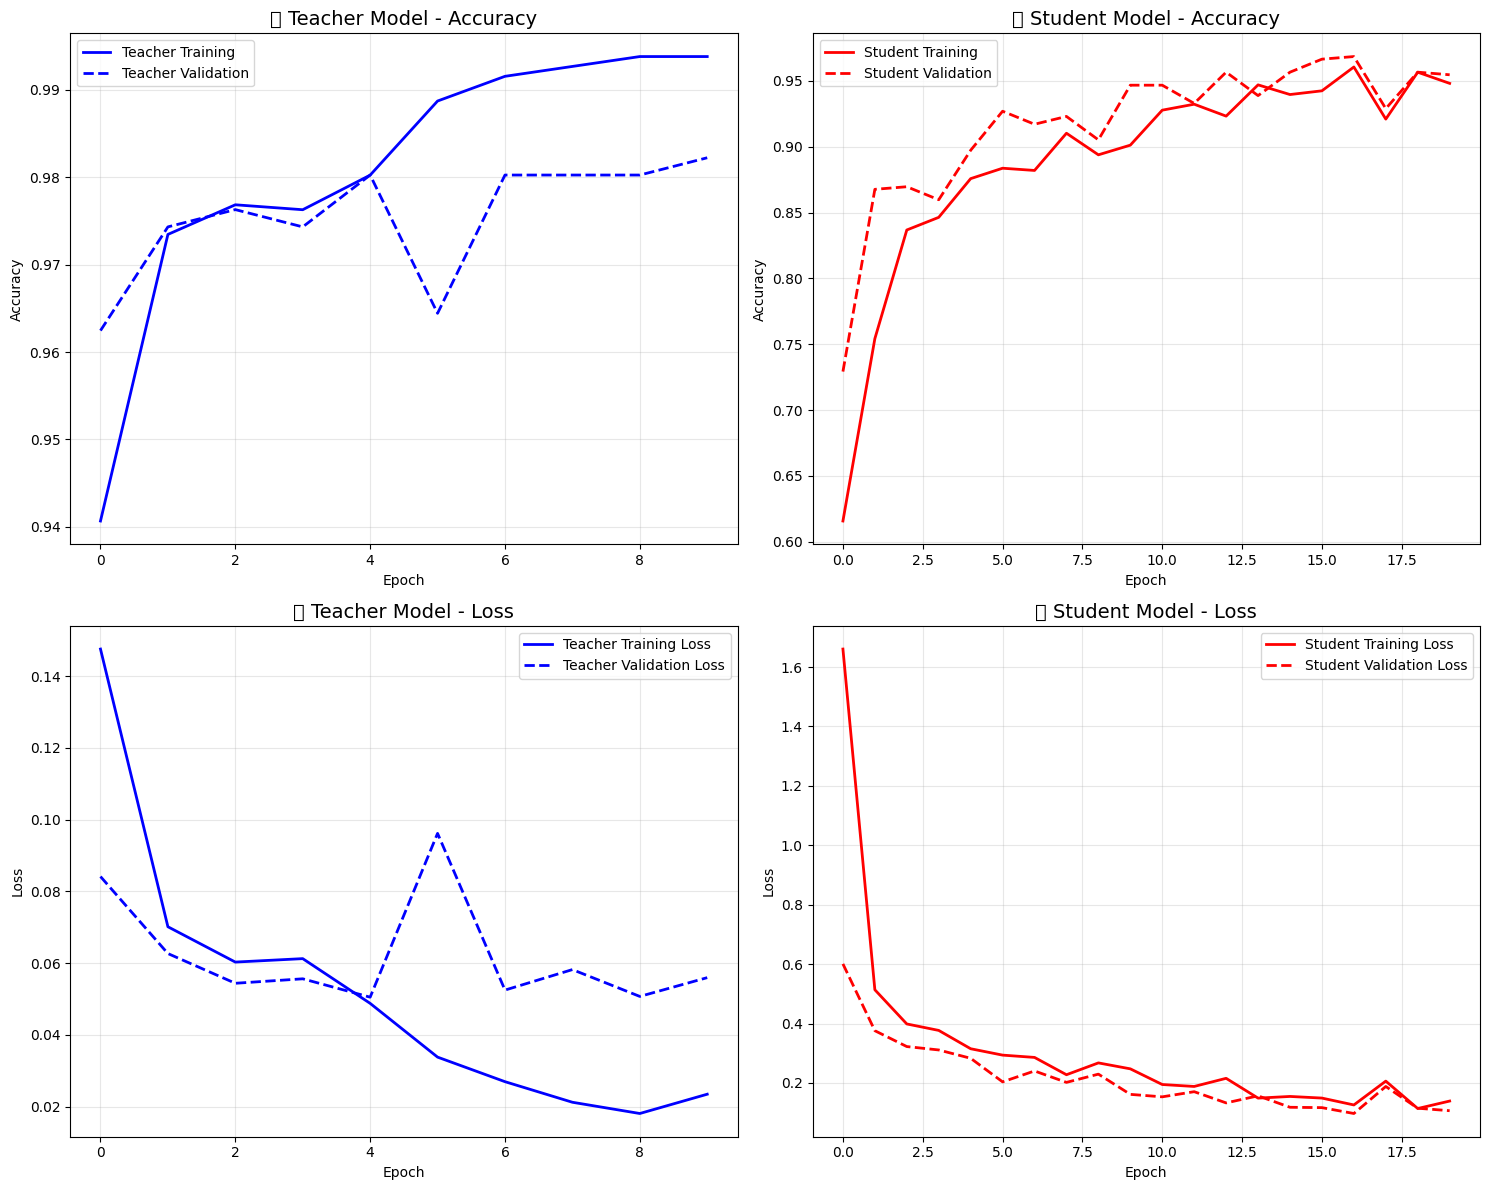


🧪 VALUTAZIONE SU TEST SET:
   🎓 Teacher Test Accuracy: 0.9802
   🎓 Teacher Test Loss: 0.0562
   🎒 Student Test Accuracy: 0.9405
   🎒 Student Test Loss: 0.1226

📈 KNOWLEDGE DISTILLATION RESULTS:
   📉 Accuracy gap: 0.0397 (3.97%)
   🎯 Knowledge retention: 96.0%


Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) DejaVu Sans.
Glyph 127890 (\N{SCHOOL SATCHEL}) missing from font(s) DejaVu Sans.
Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) DejaVu Sans.
Glyph 127890 (\N{SCHOOL SATCHEL}) missing from font(s) DejaVu Sans.


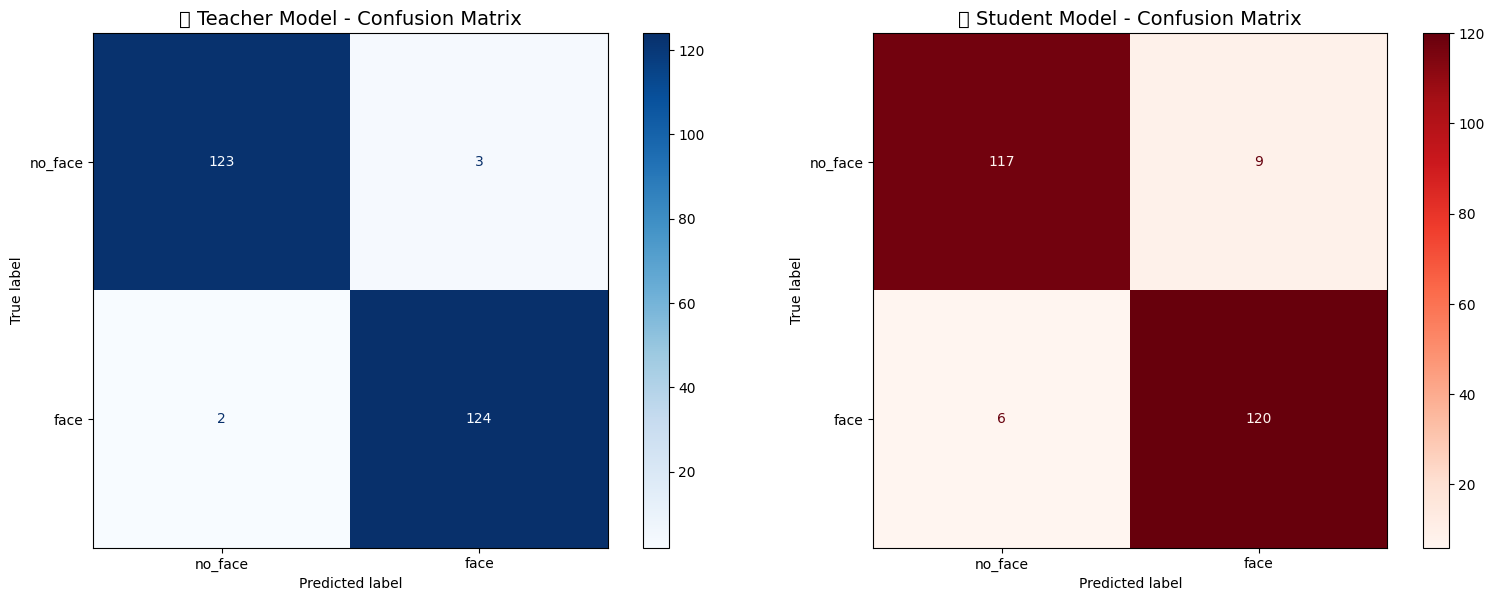


📋 TEACHER MODEL - Classification Report:
              precision    recall  f1-score   support

     no_face       0.98      0.98      0.98       126
        face       0.98      0.98      0.98       126

    accuracy                           0.98       252
   macro avg       0.98      0.98      0.98       252
weighted avg       0.98      0.98      0.98       252


📋 STUDENT MODEL - Classification Report:
              precision    recall  f1-score   support

     no_face       0.95      0.93      0.94       126
        face       0.93      0.95      0.94       126

    accuracy                           0.94       252
   macro avg       0.94      0.94      0.94       252
weighted avg       0.94      0.94      0.94       252



In [13]:
# CELLA 8 - Valutazione e matrici
print("📊 VALUTAZIONE COMPARATIVA TEACHER vs STUDENT")

# 📈 Plot confronto training history
fig, axes = plt.subplots(2, 2, figsize=(15, 12))  # Griglia 2x2

# Teacher Model History
teacher_acc = teacher_history.history['accuracy']  # Accuratezza teacher training
teacher_val_acc = teacher_history.history['val_accuracy']  # Accuratezza teacher validazione
teacher_epochs_range = range(len(teacher_acc))  # Range epoche teacher

axes[0,0].plot(teacher_epochs_range, teacher_acc, 'b-', label='Teacher Training', linewidth=2)
axes[0,0].plot(teacher_epochs_range, teacher_val_acc, 'b--', label='Teacher Validation', linewidth=2)
axes[0,0].set_title('🎓 Teacher Model - Accuracy', fontsize=14)
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Student Model History
student_acc = student_history.history['accuracy']  # Accuratezza student training
student_val_acc = student_history.history['val_accuracy']  # Accuratezza student validazione
student_epochs_range = range(len(student_acc))  # Range epoche student

axes[0,1].plot(student_epochs_range, student_acc, 'r-', label='Student Training', linewidth=2)
axes[0,1].plot(student_epochs_range, student_val_acc, 'r--', label='Student Validation', linewidth=2)
axes[0,1].set_title('🎒 Student Model - Accuracy', fontsize=14)
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Teacher Loss
teacher_loss = teacher_history.history['loss']  # Loss teacher training
teacher_val_loss = teacher_history.history['val_loss']  # Loss teacher validazione

axes[1,0].plot(teacher_epochs_range, teacher_loss, 'b-', label='Teacher Training Loss', linewidth=2)
axes[1,0].plot(teacher_epochs_range, teacher_val_loss, 'b--', label='Teacher Validation Loss', linewidth=2)
axes[1,0].set_title('🎓 Teacher Model - Loss', fontsize=14)
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Student Loss
student_loss = student_history.history['loss']  # Loss student training
student_val_loss = student_history.history['val_loss']  # Loss student validazione

axes[1,1].plot(student_epochs_range, student_loss, 'r-', label='Student Training Loss', linewidth=2)
axes[1,1].plot(student_epochs_range, student_val_loss, 'r--', label='Student Validation Loss', linewidth=2)
axes[1,1].set_title('🎒 Student Model - Loss', fontsize=14)
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Loss')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()  # Layout ottimizzato
plt.show()  # Mostra grafici

# 🧪 Valutazione su Test Set
print(f"\n🧪 VALUTAZIONE SU TEST SET:")

# Teacher evaluation
teacher_test_loss, teacher_test_acc = teacher_model.evaluate(test_ds, verbose=0)
print(f"   🎓 Teacher Test Accuracy: {teacher_test_acc:.4f}")
print(f"   🎓 Teacher Test Loss: {teacher_test_loss:.4f}")

# Student evaluation
student_test_loss, student_test_acc = student_model.evaluate(test_ds, verbose=0)
print(f"   🎒 Student Test Accuracy: {student_test_acc:.4f}")
print(f"   🎒 Student Test Loss: {student_test_loss:.4f}")

# Calcola performance gap
accuracy_gap = teacher_test_acc - student_test_acc  # Gap accuratezza
retention_rate = (student_test_acc / teacher_test_acc) * 100  # Tasso ritenzione

print(f"\n📈 KNOWLEDGE DISTILLATION RESULTS:")
print(f"   📉 Accuracy gap: {accuracy_gap:.4f} ({accuracy_gap*100:.2f}%)")
print(f"   🎯 Knowledge retention: {retention_rate:.1f}%")

# 📋 Matrici di Confusione Comparative
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Teacher Confusion Matrix
teacher_y_true, teacher_y_pred = [], []
for images, labels in test_ds:
    teacher_predictions = teacher_model.predict(images, verbose=0)
    teacher_y_true.extend(labels.numpy())
    teacher_y_pred.extend(np.argmax(teacher_predictions, axis=1))

teacher_cm = confusion_matrix(teacher_y_true, teacher_y_pred)
teacher_disp = ConfusionMatrixDisplay(confusion_matrix=teacher_cm, display_labels=class_names)
teacher_disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('🎓 Teacher Model - Confusion Matrix', fontsize=14)

# Student Confusion Matrix
student_y_true, student_y_pred = [], []
for images, labels in test_ds:
    student_predictions = student_model.predict(images, verbose=0)
    student_y_true.extend(labels.numpy())
    student_y_pred.extend(np.argmax(student_predictions, axis=1))

student_cm = confusion_matrix(student_y_true, student_y_pred)
student_disp = ConfusionMatrixDisplay(confusion_matrix=student_cm, display_labels=class_names)
student_disp.plot(ax=axes[1], cmap='Reds', values_format='d')
axes[1].set_title('🎒 Student Model - Confusion Matrix', fontsize=14)

plt.tight_layout()
plt.show()

# 📝 Report di Classificazione Comparativo
print(f"\n📋 TEACHER MODEL - Classification Report:")
print(classification_report(teacher_y_true, teacher_y_pred, target_names=class_names))

print(f"\n📋 STUDENT MODEL - Classification Report:")
print(classification_report(student_y_true, student_y_pred, target_names=class_names))

In [14]:
# CELLA 9 - Conversione Modello in TFLite

print("Conversione Modello Base in TFLite...")  # Intestazione

# CONVERSIONE MODELLO BASE in TFLite (senza quantizzazione)
# Changed 'model' to 'student_model' as it was undefined
converter_tflite = tf.lite.TFLiteConverter.from_keras_model(student_model)  # Convertitore
converter_tflite.optimizations = [tf.lite.Optimize.DEFAULT]  # Abilita ottimizzazioni
tflite_model = converter_tflite.convert()  # Conversione

# Specifica la directory per salvare il modello TFLite
tflite_models_dir = pathlib.Path("/tmp/")  # Usa una directory temporanea

# Salva il modello convertito in un file chiamato "model1.tflite", "model2.tflite", oppure "model3.tflite"
tflite_model_file = tflite_models_dir / 'model_tflite.tflite'   # Nome del file per il modello TFLite da modificare in model2 e model3
tflite_model_file.write_bytes(tflite_model)               # Scrive il contenuto del modello TFLite nel file

Conversione Modello Base in TFLite...
Saved artifact at '/tmp/tmpallve8ok'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  135112987602064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135112987602832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135112987603792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135112987604176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135112987603984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135112987598032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135112987597840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135112987599376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135112987605712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135112987599952: TensorSpec(shape=(), dtype=

33128

In [15]:
# CELLA 10 - FASE DI RIDUZIONE TFLITE QUANTIZZAZIONE INT8

# Configurazione del converter TFLite per il SavedModel
converter = tf.lite.TFLiteConverter.from_saved_model(STUDENT_MODEL_DIR)  # Crea il converter
converter.experimental_enable_resource_variables = True          # Fold delle variabili in costanti

# Creazione di un convertitore TFLite dal modello salvato
converter = tf.lite.TFLiteConverter.from_saved_model(STUDENT_MODEL_DIR)

# Abilita le ottimizzazioni predefinite per ridurre le dimensioni e migliorare l'efficienza
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Decommenta questa linea per Model 2 e Model 3

# Generazione di un dataset rappresentativo per la quantizzazione intera (da usare per il Model 3)
# Decommenta queste 5 linee sotto per ottenere il Model 3
def representative_data_gen():
  for input_value, _ in train_ds.take(100):  # Usa 100 batch di dati di TRAIN per rappresentare la distribuzione
    yield [input_value]
converter.representative_dataset = representative_data_gen  # Assegna il dataset rappresentativo
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8] # Specifica di supportare operazioni quantizzate (INT8)

# Conversione del modello in formato TFLite
tflite_model = converter.convert()

# Specifica la directory per salvare il modello TFLite
tflite_models_dir = pathlib.Path("/tmp/")  # Usa una directory temporanea

# Salva il modello convertito in un file chiamato "model1.tflite", "model2.tflite", oppure "model3.tflite"
tflite_model_file = tflite_models_dir / 'model_int.tflite'   # Nome del file per il modello TFLite da modificare in model2 e model3
tflite_model_file.write_bytes(tflite_model)               # Scrive il contenuto del modello TFLite nel file

34520

In [16]:
# CELLA 11 - Test con Validazione del modello esaminato

tflite_model_file = '/tmp/model_int.tflite'  # Specifica il percorso ed il nome del file con cui è stato salvato il modello TFLite
interpreter = tf.lite.Interpreter(model_path=tflite_model_file)  # Carica il modello TFLite e Istanzia un interprete TFLite per eseguire l'inferenza.
interpreter.allocate_tensors()  # Alloca i tensori necessari per l'inferenza

input_details = interpreter.get_input_details()[0]  # Ottiene i dettagli del tensore di input
output_details = interpreter.get_output_details()[0]  # Ottiene i dettagli del tensore di output

predictions = []  # Array per salvare le predizioni
test_labels, test_imgs = [], []  # Array per etichette e immagini di test

# Get input quantization parameters if available
input_scale, input_zero_point = input_details['quantization'] if 'quantization' in input_details and input_details['quantization'] != (0.0, 0) else (1.0, 0)

# Iterate through the test_ds dataset batch by batch
for images, labels in tqdm(test_ds.take(100)):  # cycle through 100 batches from the test dataset
    # Iterate through each image in the batch
    for i in range(images.shape[0]):
        img = images[i]  # Get the individual image
        label = labels[i].numpy()  # Get the individual label

        # Preprocess and quantize the image to INT8 if necessary
        img = tf.expand_dims(img, 0)  # Add batch dimension

        if input_details['dtype'] == np.int8:
            # Quantize the image to INT8 based on the input details
            # Assuming input is in [0, 1] range (from dataset preparation)
            img = (img / input_scale + input_zero_point).astype(input_details['dtype'])
        elif input_details['dtype'] == np.uint8:
             img = (img / input_scale + input_zero_point).astype(input_details['dtype'])


        interpreter.set_tensor(input_details['index'], img)  # Imposta il tensore di input con l'immagine singola
        interpreter.invoke()  # Esegue l'inferenza

        # Get the output tensor and dequantize if necessary
        output_data = interpreter.get_tensor(output_details['index'])
        if output_details['dtype'] == np.int8:
             scale, zero_point = output_details['quantization']
             output_data = (output_data.astype(np.float32) - zero_point) * scale # Dequantize

        predictions.append(output_data)  # Salva la predizione
        test_labels.append(label)  # Salva l'etichetta reale
        test_imgs.append(img)  # Salva l'immagine

# Nota: le iterazioni al secondo e quindi la velocità di esecuzione dell'inferenza dipende dal dispositivo su cui si fa girare il modello

score = 0  # Contatore per il numero di predizioni corrette

for item in range(len(predictions)):  # Itera su tutte le predizioni raccolte
  prediction = np.argmax(predictions[item])  # Seleziona l'indice con il valore più alto nella distribuzione di probabilità predetta e converte la predizione in una etichetta
  label = test_labels[item]  # Etichetta reale
  if prediction == label:  # Confronta predizione ed etichetta reale
    score += 1  # Incrementa il punteggio in caso di successo

print("Su " + str(len(predictions)) + " previsioni che ho ricevuto " + str(score) + " corretti")

100%|██████████| 8/8 [00:05<00:00,  1.56it/s]

Su 252 previsioni che ho ricevuto 240 corretti


INFERENZA CON MODELLO TFLITE QUANTIZZATO

📊 INFO MODELLO SELEZIONATO:
   - Percorso: /tmp/model_int.tflite
   - Quantizzazione output: Non applicata
   - Input Tensor Type: <class 'numpy.float32'>
   - Output Tensor Type: <class 'numpy.float32'>

📤 CARICA IMMAGINI PER TEST CON MODELLO QUANTIZZATO:


Saving Logo Video.png to Logo Video.png
   🔧 Preprocessing FLOAT32: range [0.000, 255.000]

🔍 ANALISI OUTPUT TFLITE:
   ✅ Somma probabilità: 1.000000

📊 RISULTATI INFERENZA:
   ⏱️ Tempo inferenza: 8.77 ms
   🚫 Confidenza NO_FACE: 0.011719 (1.17%)
   👤 Confidenza FACE: 0.988281 (98.83%)
   🎯 Classe predetta: 1 (face)
   📏 Gap confidenze: 0.976562
   📈 Confidenza massima: 0.988281
   🤖 🟢 CITOFONO ATTIVATO - Volto rilevato!
   📞 [SISTEMA CITOFONO] Chiamata in corso...
   🔔 [NOTIFICA] Visitatore rilevato all'ingresso
   📧 [LOG] Face detection: 0.988 confidence


Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.


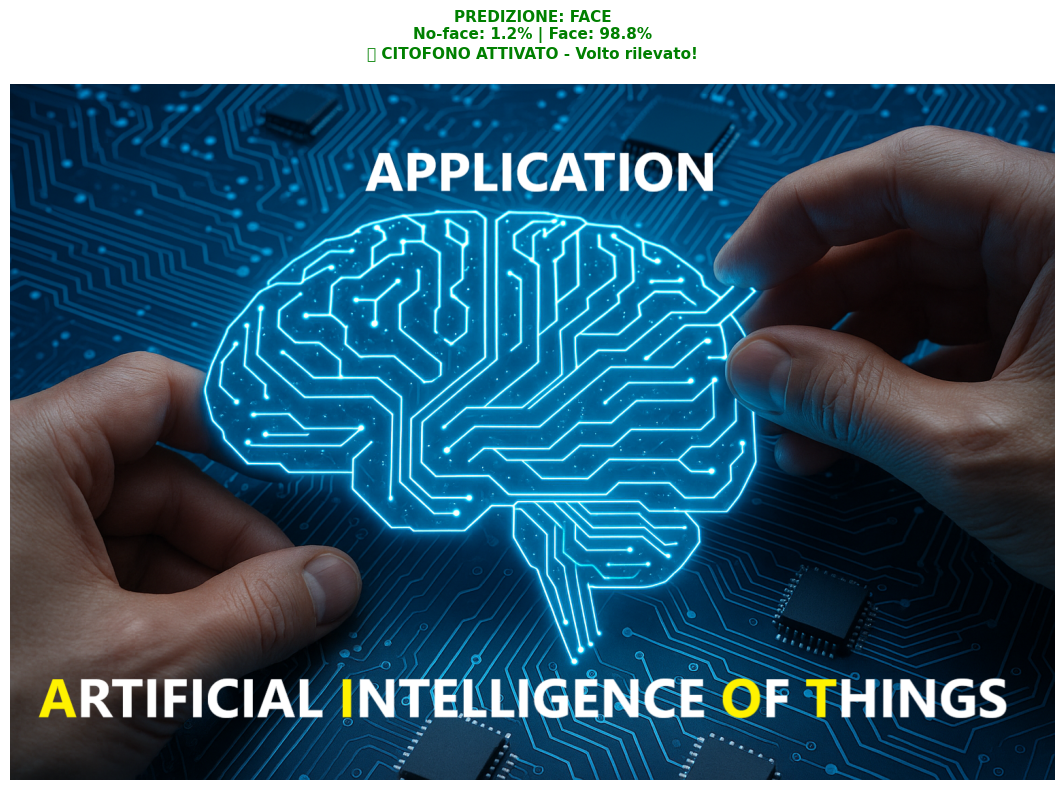


🎯 TEST TFLITE COMPLETATO - Modello pronto per produzione!


In [21]:
# CELLA 12 - Inferenza con modello quantizzato

print("INFERENZA CON MODELLO TFLITE QUANTIZZATO")  # Intestazione

# Seleziona modello ottimale FACE_DETECTION_MODEL
selected_model_path = '/tmp/model_int.tflite' # Seleziona modello ridotto con TFLite
#selected_model_path = '/tmp/model_tflite.tflite' # Seleziona modello ridotto con TFLite e Quantizzato INT8
# You might want to make this dynamic based on which model you want to test (model1, model2, or model3)
# For now, it's hardcoded to model_int.tflite

# Inizializza interprete con modello selezionato
interpreter = tf.lite.Interpreter(model_path=selected_model_path)  # Carica modello selezionato
interpreter.allocate_tensors()  # Alloca tensori

input_details = interpreter.get_input_details()  # Dettagli input
output_details = interpreter.get_output_details()  # Dettagli output

# Stampa info modello dettagliate
print(f"\n📊 INFO MODELLO SELEZIONATO:")  # Intestazione info
print(f"   - Percorso: {selected_model_path}")  # Percorso file

# Check input and output tensor types for quantization
input_dtype = input_details[0]['dtype']
output_dtype = output_details[0]['dtype']

if 'quantization' in output_details[0] and output_details[0]['quantization'][0] != 0:  # Se quantizzato
    scale = output_details[0]['quantization'][0]  # Scala
    zero_point = output_details[0]['quantization'][1]  # Zero point
    print(f"   - Quantizzazione output: scale={scale:.6f}, zero_point={zero_point}")  # Info quantizzazione
    is_quantized = True  # Flag quantizzazione
else:
    print(f"   - Quantizzazione output: Non applicata")  # Non quantizzato
    is_quantized = False  # Flag quantizzazione

print(f"   - Input Tensor Type: {input_dtype}")
print(f"   - Output Tensor Type: {output_dtype}")


def preprocess_img_tflite(path, input_details):
    """Preprocessing immagine CORRETTO per TFLite basato su CELLA 9"""
    # ⭐ CARICA IMMAGINE CON STESSO METODO DELLA CELLA 9
    img = image.load_img(path, target_size=(224, 224))  # Carica RGB automatico
    img_array = image.img_to_array(img)  # Converti a array [224, 224, 3]
    img_array = np.expand_dims(img_array, axis=0)  # Batch dimension [1, 224, 224, 3]

    # ⭐ PREPROCESSING IDENTICO AL TRAINING (Scaling to [0, 1])
    img_array_tf = tf.image.convert_image_dtype(img_array, tf.float32)  # [0, 255] -> [0, 1]
    img_array_normalized = img_array_tf.numpy()  # Converti a numpy

    # Then adapt to the TFLite model's input type based on input_details
    input_dtype = input_details['dtype']
    input_scale, input_zero_point = input_details['quantization'] if 'quantization' in input_details and input_details['quantization'] != (0.0, 0) else (1.0, 0)

    if input_dtype == np.int8:  # If input is INT8 quantized
        # Convert from [0,1] to the quantized range
        # The quantization formula is usually: quantized_value = round(float_value / scale + zero_point)
        # So, float_value = (quantized_value - zero_point) * scale
        # We need to do the inverse: quantized_value = float_value / scale + zero_point
        img_array_final = (img_array_normalized / input_scale + input_zero_point).astype(input_dtype)
        print(f"   🔧 Preprocessing INT8: range [{img_array_final.min()}, {img_array_final.max()}]")  # Debug
    elif input_dtype == np.uint8:  # If input is UINT8 quantized
         img_array_final = (img_array_normalized / input_scale + input_zero_point).astype(input_dtype)
         print(f"   🔧 Preprocessing UINT8: range [{img_array_final.min()}, {img_array_final.max()}]")  # Debug
    else:  # If input is float32
        img_array_final = img_array_normalized.astype(np.float32)  # Keep float32
        print(f"   🔧 Preprocessing FLOAT32: range [{img_array_final.min():.3f}, {img_array_final.max():.3f}]")  # Debug

    return img_array_final  # Return processed array

def analyze_tflite_output(output_raw, output_details):
    """Analizza output TFLite con gestione quantizzazione corretta"""
    print(f"\n🔍 ANALISI OUTPUT TFLITE:")  # Intestazione

    output_dtype = output_details['dtype']
    if output_dtype == np.int8 or output_dtype == np.uint8:  # If output is quantized
        # Dequantize the output
        scale, zero_point = output_details['quantization']
        dequantized = (output_raw.astype(np.float32) - zero_point) * scale  # Dequantize
        print(f"      - Valore dequantizzato: {dequantized}")  # Valore dequantizzato

        # ⭐ IMPORTANTE: The TFLite model output is [prob_no_face, prob_face]
        prob_no_face = float(dequantized[0][0])  # Probability no_face (index 0)
        prob_face = float(dequantized[0][1])     # Probability face (index 1)

    else:  # If output is float
        # ⭐ IMPORTANTE: The TFLite model output is [prob_no_face, prob_face]
        prob_no_face = float(output_raw[0][0])  # Probability no_face (index 0)
        prob_face = float(output_raw[0][1])     # Probability face (index 1)

    # Verify that probabilities sum to ~1 (softmax check)
    total_prob = prob_no_face + prob_face  # Sum
    print(f"   ✅ Somma probabilità: {total_prob:.6f}")  # Verifica softmax

    if abs(total_prob - 1.0) > 0.1:  # If sum is significantly different from 1
        print(f"   ⚠️ ATTENZIONE: Somma probabilità anomala!")  # Avviso

    return prob_no_face, prob_face  # Return probabilities


def simulate_citofono_activation(prob_face, prob_no_face, threshold_face=0.6, max_no_face=0.4, min_gap=0.2):
    """Simula attivazione citofono con logica sofisticata della CELLA 9"""
    confidence_gap = abs(prob_face - prob_no_face)  # Gap confidenze

    # SOPHISTICATED LOGIC: Multiple conditions for activation
    should_activate = (prob_face > threshold_face and           # High face confidence
                      prob_no_face < max_no_face and           # Low no_face confidence
                      confidence_gap > min_gap)                # Significant gap

    if should_activate:  # If should activate
        return "🟢 CITOFONO ATTIVATO - Volto rilevato!", True  # Activate
    else:
        return "🔴 Citofono in standby - Nessun volto", False  # Standby

# Upload images for testing
print(f"\n📤 CARICA IMMAGINI PER TEST CON MODELLO QUANTIZZATO:")  # Instructions
uploaded = files.upload()  # Upload files from user

# Perform inference on each uploaded image
results_tflite = []  # List of results
total_inference_time = 0  # Total time

for i, fname in enumerate(uploaded.keys(), 1):  # For each uploaded file
    # Preprocess image
    img_array = preprocess_img_tflite(fname, input_details[0])  # Preprocess

    # Perform inference with timing
    start_time = time.time()  # Start time
    interpreter.set_tensor(input_details[0]['index'], img_array)  # Set input
    interpreter.invoke()  # Perform inference
    inference_time = (time.time() - start_time) * 1000  # Time in ms
    total_inference_time += inference_time  # Accumulate time

    # Get output
    output_raw = interpreter.get_tensor(output_details[0]['index'])  # Raw output

    # Analyze output with quantization handling
    prob_no_face, prob_face = analyze_tflite_output(output_raw, output_details[0])  # Analyze

    # Determine predicted class
    predicted_class = 1 if prob_face > prob_no_face else 0  # 1=face, 0=no_face
    predicted_label = class_names[predicted_class]  # Class name

    # Calculate metrics
    confidence_gap = abs(prob_face - prob_no_face)  # Confidence gap
    max_confidence = max(prob_no_face, prob_face)  # Maximum confidence

    # Simulate intercom behavior with sophisticated logic
    activation_message, is_activated = simulate_citofono_activation(prob_face, prob_no_face)  # Simulate

    # 📊 Print detailed results
    print(f"\n📊 RISULTATI INFERENZA:")  # Header
    print(f"   ⏱️ Tempo inferenza: {inference_time:.2f} ms")  # Time
    print(f"   🚫 Confidenza NO_FACE: {prob_no_face:.6f} ({prob_no_face*100:.2f}%)")  # No_face
    print(f"   👤 Confidenza FACE: {prob_face:.6f} ({prob_face*100:.2f}%)")  # Face
    print(f"   🎯 Classe predetta: {predicted_class} ({predicted_label})")  # Class
    print(f"   📏 Gap confidenze: {confidence_gap:.6f}")  # Gap
    print(f"   📈 Confidenza massima: {max_confidence:.6f}")  # Max confidence
    print(f"   🤖 {activation_message}")  # Intercom status

    # Simulate full system
    if is_activated:  # If intercom activated
        print(f"   📞 [SISTEMA CITOFONO] Chiamata in corso...")  # Simulate call
        print(f"   🔔 [NOTIFICA] Visitatore rilevato all'ingresso")  # Simulate notification
        print(f"   📧 [LOG] Face detection: {prob_face:.3f} confidence")  # Log system

    # Save results
    results_tflite.append({
        'filename': fname,
        'prob_face': prob_face,
        'prob_no_face': prob_no_face,
        'predicted_class': predicted_class,
        'predicted_label': predicted_label,
        'inference_time': inference_time,
        'is_activated': is_activated,
        'confidence_gap': confidence_gap
    })

    # Display result
    plt.figure(figsize=(12, 8))  # Dimensions
    plt.imshow(image.load_img(fname))  # Show image

    # Detailed title with all info
    title_color = 'green' if is_activated else 'red'  # Color based on activation
    title_text = f"PREDIZIONE: {predicted_label.upper()}\n"  # Class
    title_text += f"No-face: {prob_no_face*100:.1f}% | Face: {prob_face*100:.1f}%\n"  # Confidences
    title_text += f"{activation_message}\n"  # Status

    plt.title(title_text, fontsize=11, color=title_color, weight='bold')  # Title
    plt.axis('off')  # Hide axes
    plt.tight_layout()  # Layout
    plt.show()  # Show

print(f"\n🎯 TEST TFLITE COMPLETATO - Modello pronto per produzione!")  # Final message